# Langkah 1 - Buat Dataset Dummy

In [1]:
import numpy as np
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

X = np.absolute(X)

X = np.round(X, 2) * 100

X = X.astype(int)

print(X)
print(y)

[[ 88 125]
 [113  63]
 [126  97]
 [ 76  54]
 [ 93 117]
 [118 119]
 [ 57 110]
 [ 89 132]
 [ 57   8]
 [ 37 163]
 [ 94  84]
 [ 20 257]
 [ 66 192]
 [ 55  34]
 [173  13]
 [269 169]
 [ 90 265]
 [  3 241]
 [ 75  85]
 [ 97 107]
 [  0 219]
 [129 129]
 [ 74  98]
 [182  11]
 [101  79]
 [ 32 182]
 [120  71]
 [138  67]
 [135  39]
 [ 14 208]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


# Langkah 2 (Opsional) - Membuat Data Frame


In [2]:
import pandas as pd

y_new = y.reshape(len(y), 1)

data = np.concatenate((X, y_new), axis=1)

nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']
df = pd.DataFrame(data, columns=nama_kolom)
df.head()

,Fitur 1,Fitur 2,Label
0,88,125,0
1,113,63,0
2,126,97,0
3,76,54,0
4,93,117,0


# Langkah 3 (Opsional) - Labeling


In [3]:
labels = {
    1: 'Kelas A',
    0: 'Kelas B'
}

df_label = df.copy()

df_label['Label'] = df_label['Label'].map(labels)
df_label.head()

,Fitur 1,Fitur 2,Label
0,88,125,Kelas B
1,113,63,Kelas B
2,126,97,Kelas B
3,76,54,Kelas B
4,93,117,Kelas B


# Langkah 4 - Visualisasi Data

C:\Users\HAMM\AppData\Local\Temp\ipykernel_71128\2700686111.py:9: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Kelas A')
C:\Users\HAMM\AppData\Local\Temp\ipykernel_71128\2700686111.py:10: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Kelas B')


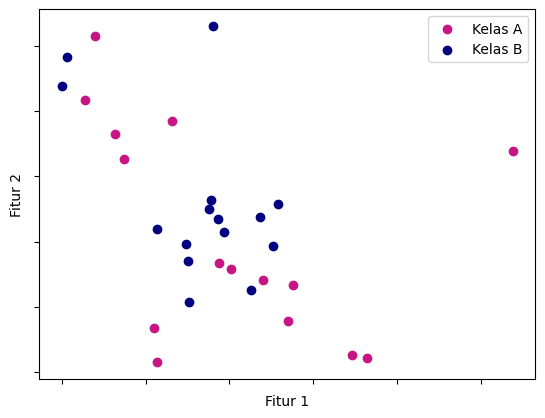

In [4]:
import matplotlib.pyplot as plt

colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

gb = df_label.groupby(['Label'])
class_a = gb.get_group('Kelas A')
class_b = gb.get_group('Kelas B')

plt.scatter(x=class_a['Fitur 1'], y=class_a['Fitur 2'], c=colors['class_a'])
plt.scatter(x=class_b['Fitur 1'], y=class_b['Fitur 2'], c=colors['class_b'])
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend(['Kelas A', 'Kelas B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

# Langkah 5 - Model Multinomial Naive Bayes

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mnb = MultinomialNB()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

mnb.fit(X_train, y_train)

y_train_pred = mnb.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = mnb.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Hasil akurasi data train: {acc_train}')
print(f'Hasil akurasi data test: {acc_test}')

Hasil akurasi data train: 0.38095238095238093
Hasil akurasi data test: 0.8888888888888888


# Langkah 6 - Model Gaussian Naive Bayes

In [6]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_train_pred_gnb = gnb.predict(X_train)
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

y_test_pred_gnb = gnb.predict(X_test)
acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f'Hasil akurasi data train (Gaussian): {acc_train_gnb}')
print(f'Hasil akurasi data test (Gaussian): {acc_test_gnb}')

Hasil akurasi data train (Gaussian): 0.6666666666666666
Hasil akurasi data test (Gaussian): 0.3333333333333333
